**Imports and Packages**

In [7]:
import Pkg; Pkg.add("FFTW"); Pkg.add("SpecialFunctions")
import Gmsh: gmsh
using Gridap, GridapGmsh
using Random, LinearAlgebra, FFTW
using Plots
using SpecialFunctions #besselk, gamma functions

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


**Generate the Uniform Triangulated Mesh**

In [8]:
function create_square_model(h)
    gmsh.initialize()
    gmsh.model.add("unit_square")
    gmsh.model.geo.addPoint(0,0,0,1,1) # last argument is optional identifier, unique per dimension
    gmsh.model.geo.addPoint(1,0,0,1,2)
    gmsh.model.geo.addPoint(1,1,0,1,3)
    gmsh.model.geo.addPoint(0,1,0,1,4)
    gmsh.model.geo.addLine(1,2,1)
    gmsh.model.geo.addLine(2,3,2) # line 2 goes from point 2 to point 3
    gmsh.model.geo.addLine(3,4,3)
    gmsh.model.geo.addLine(4,1,4)
        
    gmsh.model.geo.addCurveLoop([1,2,3,4],1)
        
    gmsh.model.geo.addPlaneSurface([1],1)

    N = Int(round(1/h))  # number of elements per edge

    gmsh.model.geo.mesh.setTransfiniteCurve(1, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(2, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(3, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(4, N+1)

    #triangulation
    gmsh.model.geo.mesh.setTransfiniteSurface(1)

    gmsh.model.geo.synchronize()

    # Define physical groups without the string argument
    edges_tag = gmsh.model.addPhysicalGroup(1, [1, 2, 3, 4])   # edges
    corners_tag = gmsh.model.addPhysicalGroup(0, [1, 2, 3, 4]) # corners
    domain_tag = gmsh.model.addPhysicalGroup(2, [1])           # surface
    
    # Set names for the physical groups
    gmsh.model.setPhysicalName(1, edges_tag, "boundary")
    gmsh.model.setPhysicalName(0, corners_tag, "boundary")
    gmsh.model.setPhysicalName(2, domain_tag, "domain")
    gmsh.model.mesh.generate(2)

    model = GmshDiscreteModel(gmsh);
    gmsh.finalize();
    return model
end


create_square_model (generic function with 1 method)

**Algorithm 1 and Algorithm 2 from "analysis of circulant embedding method for sampling stationary random fields - i graham"**

In [9]:
rho_exp(r, v, p) = v^2 * exp(-p*r)
function rho_matern(d, σ, v, p)
    if d == 0
        return σ^2
    end
    return σ^2 * (2.0^(1-v) / gamma(v)) * (sqrt(2*v) * d / p)^v * besselk(v, (sqrt(2*v) * d / p))
end

function algorithm1(m0, σ, v, p)
    #step 1
    m  = m0
    h0 = 1 / m0
    
    while true
        ℓ = m * h0
        n = 2m
        s = n^2
        r = zeros(Float64, s) #R_ext is a s x s, so the column r will be a s x 1 vector
        
        #step 2 calc r
        for k1 in 1:n, k2 in 1:n
            x1 = h0 * (k1-1)
            x2 = h0 * (k2-1)
            
            #rho_ext = rho(φ(x₁),φ(x₂)) from paper, where φ(x) = x if 0 < x < ℓ or φ(x) = 2ℓ-x if ℓ < x < 2ℓ
            # φ(x₁)
            if x1 < ℓ
                φ1 = x1
            else
                φ1 = 2ℓ - x1
            end
            
            #φ(x₂)
            if x2 < ℓ
                φ2 = x2
            else
                φ2 = 2ℓ - x2
            end

            idx = k1 + (k2-1)*n   #vector ordering
            r[idx] = rho_matern(sqrt(φ1^2 + φ2^2), σ, v, p)
        end

        
        #step 3, calc v (in this case λ because I already have variable v)
        λ = real.(fft(reshape(r, n, n))) #reshape to be able to take fft

        #step 4
        if minimum(λ) >= 0
            return m, λ
        end

        m += 1
    end
end

function algorithm2(m0, m, λ, rng)
    #step 1
    n = 2m
    s = n^2
    y = randn(rng, n, n)

    #step 2
    y .*= sqrt.(λ)

    #step 3
    w = fft(y) / sqrt(s)  

    #step 4
    w = real.(w) .+ imag.(w)

    #step 5
    z = w[1:(m0+1), 1:(m0+1)]

    return z
end

function q_true(m0, σ, v, p, point1, point2)
    ix, iy = point1
    jx, jy = point2
    x1, y1 = ix/m0, iy/m0
    x2, y2 = jx/m0, jy/m0
    #return rho_exp(sqrt((x1-y1)^2 + (x2-y2)^2), v, p)
    return rho_matern(sqrt((x1-x2)^2 + (y1-y2)^2), σ, v, p)
end


q_true (generic function with 1 method)

**Grid Visualization**

In [10]:
h = 1/128

σ  = 1
v = 0.4
p  = 0.15

model = create_square_model(h)

reffe = ReferenceFE(lagrangian,Float64,1)

V = TestFESpace(model,reffe,conformity=:H1)
U = TrialFESpace(V)

m0 = Int(round(1/h))

rng=MersenneTwister(4545)

m, λ = algorithm1(m0, σ, v, p)
Z = algorithm2(m0, m, λ, rng)


function f(x)

    #convert coordinate to grid index
    i = clamp(Int(round(x[1]/h))+1,1,m0+1)
    j = clamp(Int(round(x[2]/h))+1,1,m0+1)

    return Z[i,j]
end

zh = interpolate_everywhere(f,U)

Ω = Triangulation(model)

writevtk(Ω,"random_field",cellfields=["Z"=>zh])

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000183471s, CPU 0.000169s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Transfinite)
Info    : Done meshing 2D (Wall 0.00193648s, CPU 0.00174s)
Info    : 16641 nodes 33284 elements


(["random_field.vtu"],)

**Monte Carlo Check for Convergence of the Covariance**

In [11]:
function check_covariance_convergence(m0, σ, v, p, N, point1, point2, rng)

    m, λ = algorithm1(m0, σ, v, p)

    ix, iy = point1
    jx, jy = point2

    running = zeros(Float64, N)
    sxy = 0.0

    for n in 1:N
        Z = algorithm2(m0, m, λ, rng)

        X = Z[ix, iy]
        Y = Z[jx, jy]

        sxy += X*Y
        running[n] = sxy / n
    end

    q = q_true(m0, σ, v, p, point1, point2)

    return running, q
end

check_covariance_convergence (generic function with 1 method)

q = 0.8463644043934987
qhat(end) = 0.8640398343993729


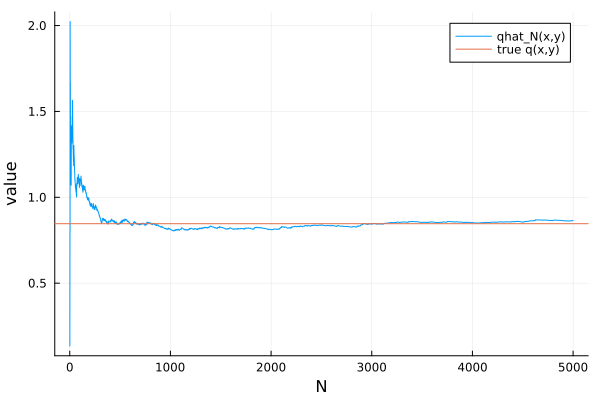

In [12]:
running, q = check_covariance_convergence(m0, σ, v, p, 5000, (21,25), (22,27), rng)

println("q = ", q)
println("qhat(end) = ", running[end])

plot(running, label="qhat_N(x,y)")
hline!([q], label="true q(x,y)")
xlabel!("N")
ylabel!("value")